In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def cf_mat(k,h):
    A = np.array([[0, 1], [-k, 0]])
    M = np.eye(len(A)) + h*A
    return M

def e_values(M):
    evs = np.linalg.eigvals(M)
    mev = np.max(np.abs(evs))
    return evs, mev

At h = 0.01

 Eigenvalues (λ) = [1.+0.01j 1.-0.01j]

 Max Eigenvalue (λ) = 1.0000499987500624

 Solution may not be Entirely Stable ;) 

At h = 0.1

 Eigenvalues (λ) = [1.+0.1j 1.-0.1j]

 Max Eigenvalue (λ) = 1.004987562112089

 Solution may not be Entirely Stable ;) 

At h = 0.5

 Eigenvalues (λ) = [1.+0.5j 1.-0.5j]

 Max Eigenvalue (λ) = 1.118033988749895

 Solution may not be Entirely Stable ;) 

At h = 1.0

 Eigenvalues (λ) = [1.+1.j 1.-1.j]

 Max Eigenvalue (λ) = 1.4142135623730951

 Solution may not be Entirely Stable ;) 



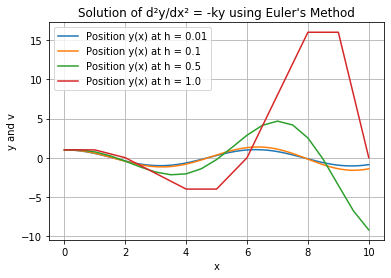

In [14]:
# Define the parameters

k = 1.0        # Constant in the equation (e.g., spring constant)
h_arr = [0.01, 0.1, 0.5, 1.0]# Step size
x_start = 0    # Start of the interval
x_end = 10     # End of the interval
y_0 = 1.0      # Initial condition for y
v_0 = 0.0      # Initial condition for dy/dx

for h in h_arr:
    # Create arrays to store x, y, and v values

    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions

    y_values[0] = y_0
    v_values[0] = v_0



    # Euler's Method loop

    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]    

        # Update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)
    
    plt.plot(x_values, y_values, label=f'Position y(x) at h = {h}')
    
    M = cf_mat(k,h)
    eigenvalues, max_eigenvalues = e_values(M)
    
     
    print(f"At h = {h}")
    print(f"\n Eigenvalues (λ) = {eigenvalues}")
    print(f"\n Max Eigenvalue (λ) = {max_eigenvalues}")

    if max_eigenvalues < 1:
        print("\n Solution is Stable \n")
    else:
        print("\n Solution may not be Entirely Stable ;) \n")

plt.xlabel('x')
plt.ylabel('y and v')
plt.legend()
plt.title('Solution of d²y/dx² = -ky using Euler\'s Method')
plt.grid(True)
